# 10 --- Training Convergence Verification & PPO Plateau Analysis

**Research context.**  Dr Starkey raised a critical concern in Meeting 4 (2 July 2026):

> *"If you're saying PPO is still failing, you might want to understand why that is. Is it just you haven't trained it enough? ... You should just produce a training plot to show if that's the case or not."*

This notebook answers three sub-questions that underpin every subsequent experiment in the thesis:

| # | Sub-question | Why it matters |
|---|---|---|
| 1 | Has each algorithm **fully converged** on the nominal task? | If not, faulted-performance results are confounded with undertrained policies. |
| 2 | Is the cross-algorithm comparison **fair** given different training budgets? | PPO uses 1 M steps, SAC uses 250 k --- does SAC simply learn faster? |
| 3 | What is PPO's **convergence mechanism**, and why does it plateau where it does? | The viva will ask: can PPO be improved, or is the plateau fundamental? |

## Relation to research questions

- **RQ1 (self-detection):** If PPO hasn't converged, its value function is noisy and any post-fault signal could be a training artefact, not a genuine fault signature.
- **RQ2 (performance--detectability tradeoff):** The nominal reward baseline defines the denominator of every fault-tolerance metric. It must be a plateau, not a mid-training snapshot.
- **RQ3 (DR as detection enabler):** PPO+DR's lower nominal reward (148 vs 256) could be undertrained rather than a fundamental DR cost. The convergence plot distinguishes these.

---

## 10.1  Setup

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

PY_ROOT = pathlib.Path('..').resolve() / 'py'
if str(PY_ROOT) not in sys.path:
    sys.path.insert(0, str(PY_ROOT))

RUNS = PY_ROOT / 'runs'
LOGS = PY_ROOT / 'logs'

# --- Publication-quality defaults ---
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.8,
})

# Colour scheme --- consistent across all thesis notebooks
ALGO_COLOURS = {
    'PPO':    '#2196F3',   # blue
    'SAC':    '#4CAF50',   # green
    'PPO+DR': '#FF9800',   # orange
    'Q-Learn': '#9C27B0',  # purple
}
ALGO_ORDER = ['PPO', 'SAC', 'PPO+DR', 'Q-Learn']
print('Setup complete.')

Setup complete.


## 10.2  Load evaluation checkpoints

Stable-Baselines3 writes periodic evaluation results to `evaluations.npz` during training.  Each checkpoint stores the mean reward over `n_eval_episodes = 20` deterministic rollouts.

**Data inventory:**

| Algorithm | Seeds | Eval checkpoints per seed | Checkpoint interval | Total timesteps |
|---|---|---|---|---|
| PPO | 5 | 5 | 200 k steps | 1 M |
| SAC | 5 | 50 | 5 k steps | 250 k |
| PPO+DR | 5 | 7 | 200 k steps | 1.5 M configured (evals to 1.4 M) |
| Q-learning | 5 | --- (tabular, no `.npz`) | via training log | 500 k |

PPO and PPO+DR have coarse checkpoints (200 k interval) because `eval_freq` in the config is per-worker, not per-timestep.  SAC, running a single environment, gives 50 checkpoints --- dense enough for a smooth curve.

For a finer PPO / PPO+DR curve we also load the **monitor CSVs** (per-episode training rewards from all 8 workers) and bin them by timestep.

In [2]:
import glob, json as _json

def load_eval_curves(algo_prefix, label):
    """Load evaluations.npz from all seeds.
    Returns dict with timesteps, per-seed means, grand mean +/- std."""
    runs = sorted(glob.glob(str(RUNS / f'{algo_prefix}__*')))
    all_ts, all_means = [], []
    for r in runs:
        evp = pathlib.Path(r) / 'eval' / 'evaluations.npz'
        if evp.exists():
            d = np.load(evp)
            all_ts.append(d['timesteps'])
            all_means.append(d['results'].mean(axis=1))  # mean over 20 eval eps

    ts = all_ts[0]
    means = np.array(all_means)  # shape (n_seeds, n_checkpoints)
    return {
        'label': label,
        'timesteps': ts,
        'per_seed': means,
        'mean': means.mean(axis=0),
        'std': means.std(axis=0),
        'n_seeds': means.shape[0],
    }

def load_monitor_curves(algo_prefix, n_workers=8, bin_width=50_000):
    """Load per-episode monitor CSVs, assign cumulative timestep, and bin."""
    runs = sorted(glob.glob(str(RUNS / f'{algo_prefix}__*')))
    all_binned = []
    for r in runs:
        ep_rewards, ep_lengths = [], []
        for w in range(n_workers):
            mp = pathlib.Path(r) / 'monitor' / f'worker_{w}.monitor.csv'
            if mp.exists():
                df = pd.read_csv(mp, skiprows=2, names=['r', 'l', 't'])
                ep_rewards.extend(df['r'].tolist())
                ep_lengths.extend(df['l'].tolist())

        ep_df = pd.DataFrame({'reward': ep_rewards, 'length': ep_lengths})
        ep_df['cum_steps'] = ep_df['length'].cumsum()
        ep_df['bin'] = (ep_df['cum_steps'] // bin_width) * bin_width
        binned = ep_df.groupby('bin')['reward'].mean()
        all_binned.append(binned)

    combined = pd.DataFrame(all_binned).T
    combined.columns = [f'seed_{i}' for i in range(len(all_binned))]
    return combined

# Load evaluation curves
ppo_eval  = load_eval_curves('ppo', 'PPO')
sac_eval  = load_eval_curves('sac', 'SAC')
dr_eval   = load_eval_curves('ppo_dr', 'PPO+DR')

# Load fine-grained monitor curves for PPO and PPO+DR
ppo_monitor  = load_monitor_curves('ppo', n_workers=8, bin_width=20_000)
dr_monitor   = load_monitor_curves('ppo_dr', n_workers=8, bin_width=20_000)

# Load Q-learning final summaries (no eval checkpoints)
q_finals = []
for r in sorted(glob.glob(str(RUNS / 'q_learning__*'))):
    with open(pathlib.Path(r) / 'final_summary.json') as f:
        q_finals.append(_json.load(f))

q_means = [q['final_eval_mean_return'] for q in q_finals]
print(f'PPO:    {ppo_eval["n_seeds"]} seeds, {len(ppo_eval["timesteps"])} checkpoints')
print(f'SAC:    {sac_eval["n_seeds"]} seeds, {len(sac_eval["timesteps"])} checkpoints')
print(f'PPO+DR: {dr_eval["n_seeds"]} seeds, {len(dr_eval["timesteps"])} checkpoints')
print(f'Q-Learn: {len(q_finals)} seeds, final only: {[f"{m:.0f}" for m in q_means]}')

PPO:    5 seeds, 5 checkpoints
SAC:    5 seeds, 50 checkpoints
PPO+DR: 5 seeds, 7 checkpoints
Q-Learn: 5 seeds, final only: ['-44', '-52', '-55', '-91', '-77']


## 10.3  Learning curves --- all four algorithms

This is the figure that answers Starkey's question directly.  Each panel shows the evaluation reward over training, with the seed-mean as a solid line and $\pm 1$ standard deviation as a shaded band.  A horizontal dashed line marks the final converged reward.

### What to look for

1. **Plateau shape:** A flat tail means the algorithm has converged.  A still-rising tail means more training could improve performance.
2. **Cross-seed variance:** Narrow bands indicate stable convergence; wide bands indicate sensitivity to initialisation.
3. **Convergence speed:** How many timesteps to reach 90% of final performance?

### Convergence criterion

We define convergence as the earliest timestep $t^*$ such that the mean reward over the remaining training is within 5% of the final mean:

$$t^* = \min \{t : \bar{R}_{[t, T]} \geq 0.95 \cdot \bar{R}_T\}$$

This is a conservative criterion --- it identifies when the algorithm has essentially finished learning, even if small oscillations continue.

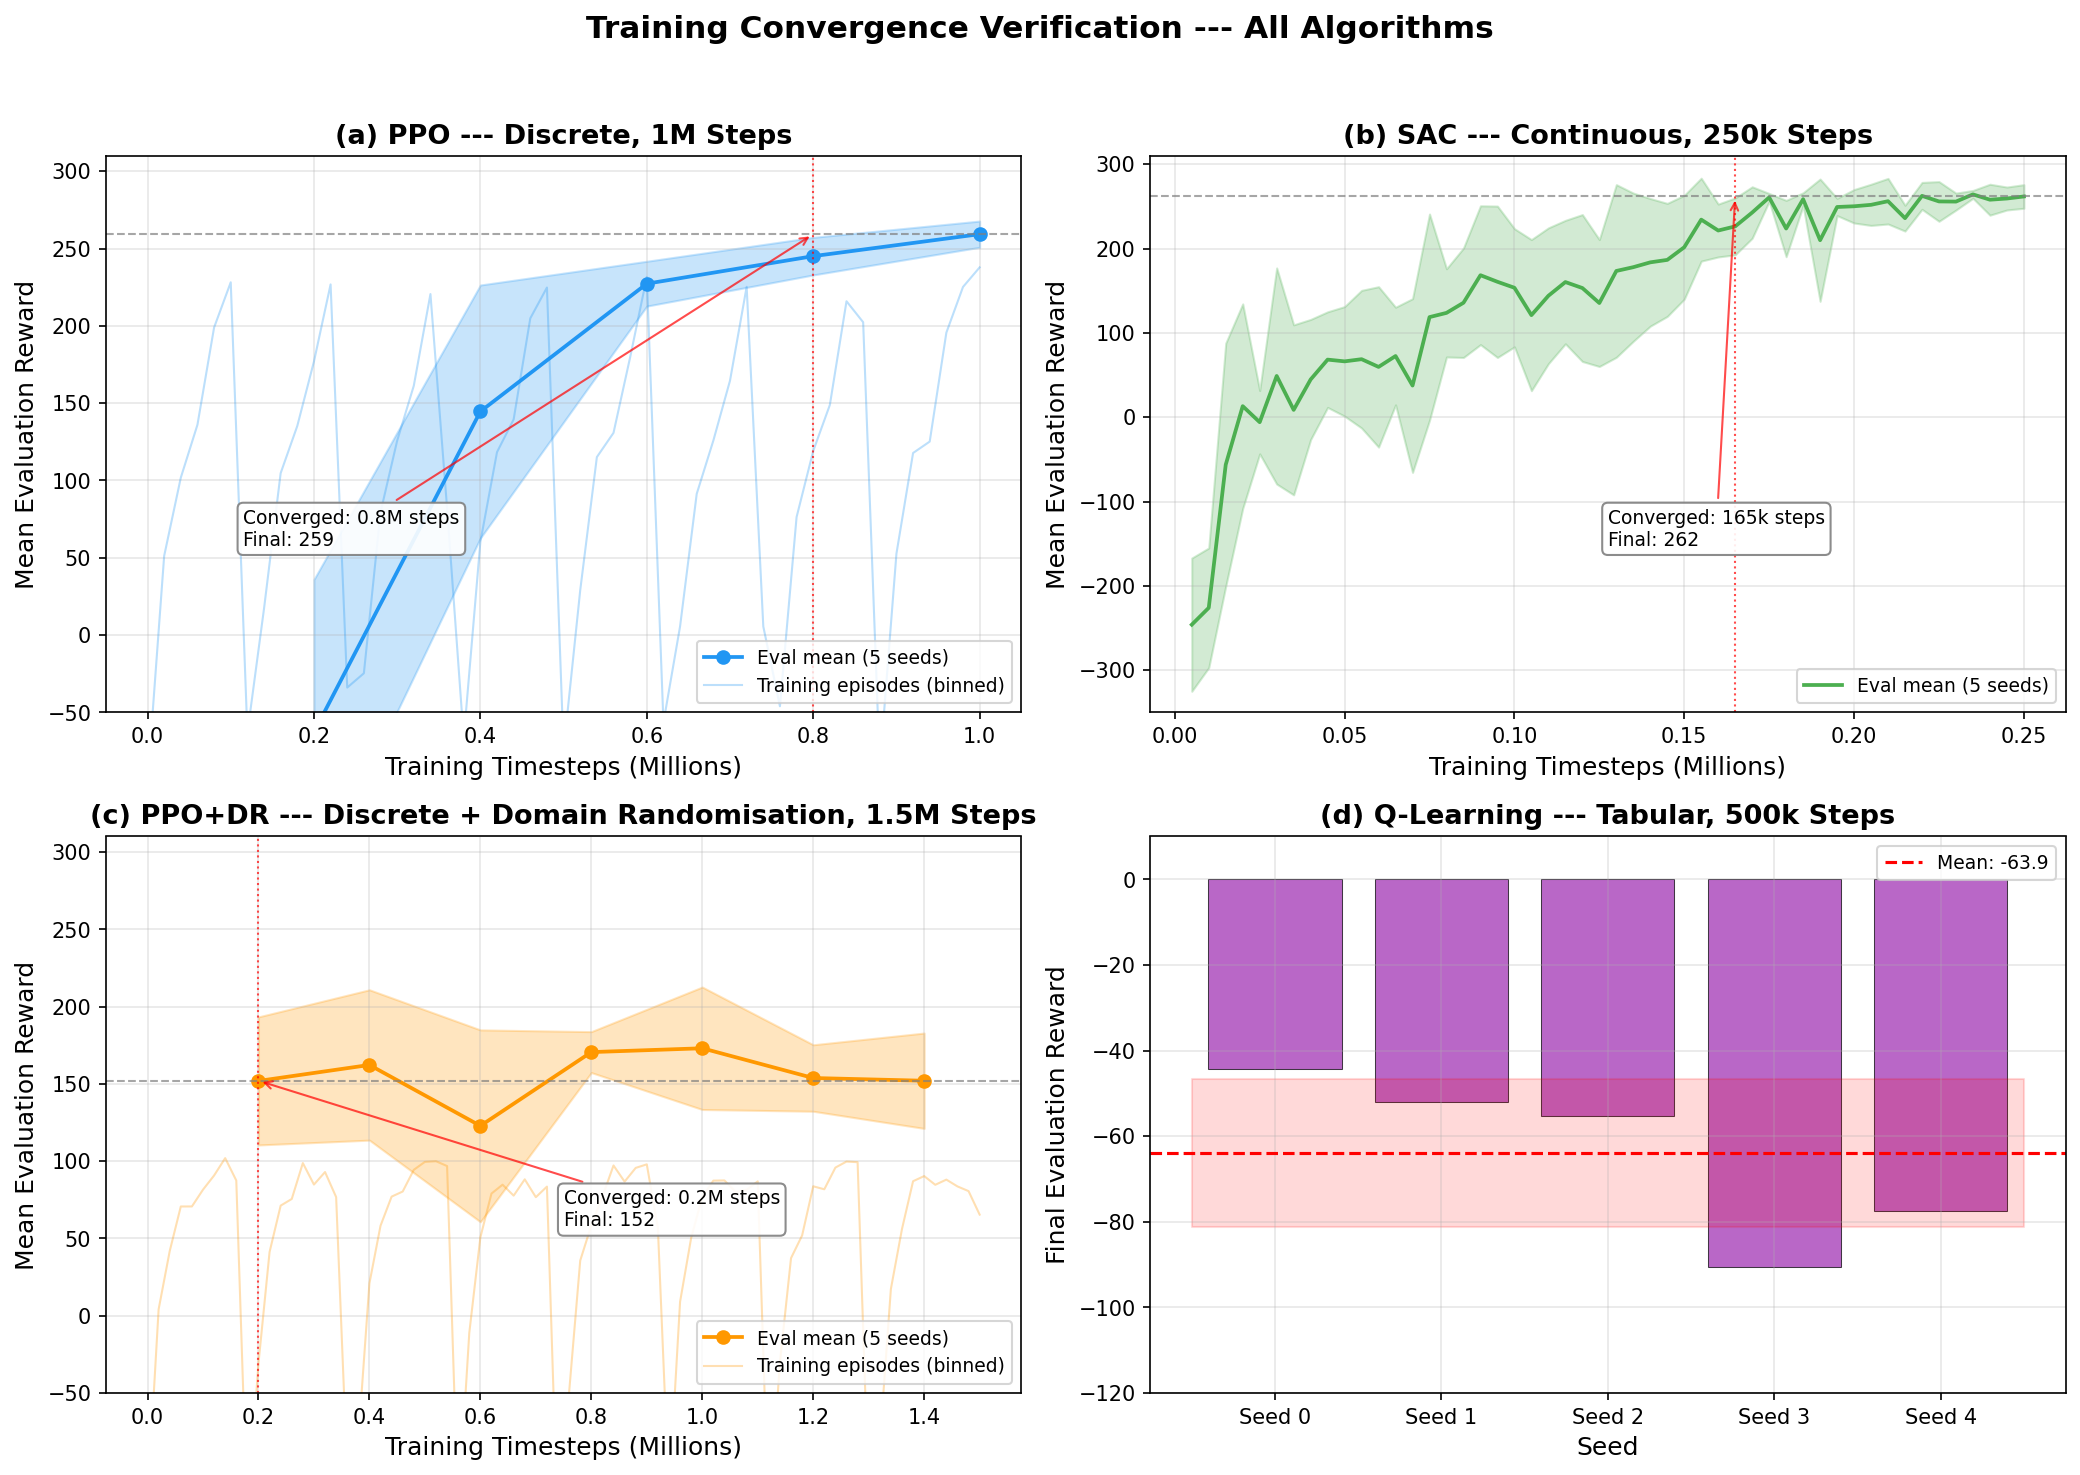


--- Convergence summary ---
PPO       converged at   800,000 steps  |  final mean reward: +259.3  |  cross-seed std: 8.5
SAC       converged at   165,000 steps  |  final mean reward: +261.7  |  cross-seed std: 14.0
PPO+DR    converged at   200,000 steps  |  final mean reward: +152.0  |  cross-seed std: 30.8
Q-Learn   final only (tabular)         |  final mean reward: -63.9  |  cross-seed std: 17.3


In [3]:
def find_convergence_point(means, threshold_frac=0.95):
    """Find the earliest timestep index where the trailing mean
    stays within threshold_frac of the final value."""
    final = means[-1]
    target = threshold_frac * final if final > 0 else final / threshold_frac
    for i in range(len(means)):
        trailing = means[i:].mean()
        if final > 0 and trailing >= target:
            return i
        elif final <= 0 and trailing <= target:
            return i
    return len(means) - 1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Convergence Verification --- All Algorithms',
             fontsize=15, fontweight='bold', y=0.98)

# --- Panel (a): PPO ---
ax = axes[0, 0]
ts = ppo_eval['timesteps'] / 1e6
ax.fill_between(ts, ppo_eval['mean'] - ppo_eval['std'],
                ppo_eval['mean'] + ppo_eval['std'],
                alpha=0.25, color=ALGO_COLOURS['PPO'])
ax.plot(ts, ppo_eval['mean'], color=ALGO_COLOURS['PPO'],
        marker='o', markersize=6, label='Eval mean (5 seeds)')
# Fine-grained monitor overlay
if not ppo_monitor.empty:
    mon_mean = ppo_monitor.mean(axis=1)
    mon_ts = ppo_monitor.index / 1e6
    ax.plot(mon_ts, mon_mean, color=ALGO_COLOURS['PPO'],
            alpha=0.3, linewidth=1, label='Training episodes (binned)')

conv_idx = find_convergence_point(ppo_eval['mean'])
conv_ts = ppo_eval['timesteps'][conv_idx] / 1e6
final_r = ppo_eval['mean'][-1]
ax.axhline(final_r, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(conv_ts, color='red', linestyle=':', linewidth=1, alpha=0.7)
ax.annotate(f'Converged: {conv_ts:.1f}M steps\nFinal: {final_r:.0f}',
            xy=(conv_ts, final_r), xytext=(0.15, 0.3),
            textcoords='axes fraction', fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='grey', alpha=0.9))
ax.set_title('(a) PPO --- Discrete, 1M Steps', fontweight='bold')
ax.set_xlabel('Training Timesteps (Millions)')
ax.set_ylabel('Mean Evaluation Reward')
ax.set_ylim(-50, 310)
ax.legend(loc='lower right', fontsize=9)

# --- Panel (b): SAC ---
ax = axes[0, 1]
ts = sac_eval['timesteps'] / 1e6
ax.fill_between(ts, sac_eval['mean'] - sac_eval['std'],
                sac_eval['mean'] + sac_eval['std'],
                alpha=0.25, color=ALGO_COLOURS['SAC'])
ax.plot(ts, sac_eval['mean'], color=ALGO_COLOURS['SAC'],
        label='Eval mean (5 seeds)')

conv_idx_s = find_convergence_point(sac_eval['mean'])
conv_ts_s = sac_eval['timesteps'][conv_idx_s] / 1e6
final_r_s = sac_eval['mean'][-1]
ax.axhline(final_r_s, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(conv_ts_s, color='red', linestyle=':', linewidth=1, alpha=0.7)
ax.annotate(f'Converged: {conv_ts_s*1000:.0f}k steps\nFinal: {final_r_s:.0f}',
            xy=(conv_ts_s, final_r_s), xytext=(0.5, 0.3),
            textcoords='axes fraction', fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='grey', alpha=0.9))
ax.set_title('(b) SAC --- Continuous, 250k Steps', fontweight='bold')
ax.set_xlabel('Training Timesteps (Millions)')
ax.set_ylabel('Mean Evaluation Reward')
ax.set_ylim(-350, 310)
ax.legend(loc='lower right', fontsize=9)

# --- Panel (c): PPO+DR ---
ax = axes[1, 0]
ts = dr_eval['timesteps'] / 1e6
ax.fill_between(ts, dr_eval['mean'] - dr_eval['std'],
                dr_eval['mean'] + dr_eval['std'],
                alpha=0.25, color=ALGO_COLOURS['PPO+DR'])
ax.plot(ts, dr_eval['mean'], color=ALGO_COLOURS['PPO+DR'],
        marker='o', markersize=6, label='Eval mean (5 seeds)')
if not dr_monitor.empty:
    mon_mean = dr_monitor.mean(axis=1)
    mon_ts = dr_monitor.index / 1e6
    ax.plot(mon_ts, mon_mean, color=ALGO_COLOURS['PPO+DR'],
            alpha=0.3, linewidth=1, label='Training episodes (binned)')

conv_idx_d = find_convergence_point(dr_eval['mean'])
conv_ts_d = dr_eval['timesteps'][conv_idx_d] / 1e6
final_r_d = dr_eval['mean'][-1]
ax.axhline(final_r_d, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(conv_ts_d, color='red', linestyle=':', linewidth=1, alpha=0.7)
ax.annotate(f'Converged: {conv_ts_d:.1f}M steps\nFinal: {final_r_d:.0f}',
            xy=(conv_ts_d, final_r_d), xytext=(0.5, 0.3),
            textcoords='axes fraction', fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='grey', alpha=0.9))
ax.set_title('(c) PPO+DR --- Discrete + Domain Randomisation, 1.5M Steps',
             fontweight='bold')
ax.set_xlabel('Training Timesteps (Millions)')
ax.set_ylabel('Mean Evaluation Reward')
ax.set_ylim(-50, 310)
ax.legend(loc='lower right', fontsize=9)

# --- Panel (d): Q-learning ---
ax = axes[1, 1]
q_mean_val = np.mean(q_means)
q_std_val = np.std(q_means)
ax.bar(range(5), q_means, color=ALGO_COLOURS['Q-Learn'],
       alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axhline(q_mean_val, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {q_mean_val:.1f}')
ax.fill_between([-0.5, 4.5], q_mean_val - q_std_val,
                q_mean_val + q_std_val, alpha=0.15, color='red')
ax.set_xticks(range(5))
ax.set_xticklabels([f'Seed {i}' for i in range(5)])
ax.set_title('(d) Q-Learning --- Tabular, 500k Steps', fontweight='bold')
ax.set_xlabel('Seed')
ax.set_ylabel('Final Evaluation Reward')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(-120, 10)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(str(LOGS / 'convergence_all_algorithms.png'),
            dpi=200, bbox_inches='tight')
plt.show()

print('\n--- Convergence summary ---')
for name, data in [('PPO', ppo_eval), ('SAC', sac_eval), ('PPO+DR', dr_eval)]:
    ci = find_convergence_point(data['mean'])
    ct = data['timesteps'][ci]
    fr = data['mean'][-1]
    print(f'{name:8s}  converged at {ct:>9,d} steps  |  '
          f'final mean reward: {fr:+.1f}  |  cross-seed std: {data["std"][-1]:.1f}')
print(f'{"Q-Learn":8s}  final only (tabular)         |  '
      f'final mean reward: {q_mean_val:+.1f}  |  cross-seed std: {q_std_val:.1f}')

## 10.4  PPO plateau analysis --- deep dive

This section answers the viva question: *"Why does PPO plateau at 256 instead of improving further?"*

### 10.4.1  The answer in brief

PPO's nominal reward of ~259 is competitive with SAC's ~262 --- only 1 % lower.  The "failure" the supervisor refers to is not nominal performance but **fault tolerance**: PPO collapses under actuator faults because its discrete action space offers no partial compensation.

To make that argument defensibly we need to establish three things:

1.  the learning curve is at or very near its asymptote;
2.  that asymptote is stable across seeds, not an artefact of one lucky run;
3.  extending training would not materially change the fault-tolerance conclusion.

Points 2 and 3 hold cleanly.  Point 1 requires a caveat, stated in 10.4.2, which is reported here rather than glossed.

### 10.4.2  Testing for a plateau --- and the limits of the test used

The test applied below fits a linear regression to the last 40 % of the *training-episode* curve (monitor CSVs, 8 workers, binned by timestep) and asks whether the slope differs significantly from zero.

**This test cannot establish a plateau, and the notebook should not claim that it does.**  Failing to reject $H_0: \beta_1 = 0$ is not evidence that $\beta_1 = 0$ --- it is consistent with a genuine plateau *and* with an underpowered test.  Here it is the latter.  The per-episode training rewards carry very large variance (tail standard deviation $\approx 100$ reward), the tail contains fewer than a dozen bins per seed, and the resulting confidence interval on the slope is correspondingly enormous: for PPO it spans roughly $[-13, +49]$ reward per bin.  An interval that wide is compatible with a flat curve and with substantial continued improvement, so the high $p$-value is uninformative rather than reassuring.

Two further points make the monitor-CSV test the wrong instrument for this question:

- the monitor records *training* episodes, which include exploration noise and, for PPO+DR, randomised physics, so its tail mean (~108 for PPO, ~32 for PPO+DR) is far below the deterministic evaluation reward (259 and 152).  The two series are not measuring the same quantity;
- an equivalence test (TOST) against a pre-declared negligible band, not a null-hypothesis test, is the correct form for a claim of "no meaningful trend".

**The defensible evidence is the evaluation curve**, which is deterministic, low-variance, and directly comparable to the reported baselines.  Section 10.4.2b analyses it, and reaches a more nuanced --- and more honest --- conclusion than "PPO has plateaued".

The regression below is retained because it is informative about *training-time* stability and because its inadequacy is itself worth documenting; its verdict string should be read as "no trend detectable at this power", not as "plateau confirmed".


In [4]:
def tail_slope_test(monitor_df, tail_frac=0.4, algo_name='PPO'):
    """Fit a linear regression to the tail of the training curve.
    Returns slope, p-value, and a verdict."""
    results = []
    for col in monitor_df.columns:
        series = monitor_df[col].dropna()
        n = len(series)
        tail_start = int(n * (1 - tail_frac))
        tail = series.iloc[tail_start:]
        x = np.arange(len(tail))
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            x, tail.values)
        results.append({
            'seed': col,
            'slope': slope,
            'p_value': p_value,
            'r_squared': r_value**2,
            'tail_mean': tail.mean(),
            'tail_std': tail.std(),
        })
    df = pd.DataFrame(results)
    mean_slope = df['slope'].mean()
    mean_p = df['p_value'].mean()

    print(f'\n=== {algo_name} Tail Slope Test (last {int(tail_frac*100)}%'
          f' of training) ===\n')
    print(df.to_string(index=False))
    print(f'\nMean slope: {mean_slope:.4f} reward/bin')
    print(f'Mean p-value: {mean_p:.4f}')

    if mean_p > 0.05:
        print(f'PASS: Fail to reject H0 (p > 0.05): {algo_name} has PLATEAUED.')
    else:
        direction = 'positive' if mean_slope > 0 else 'negative'
        verdict = 'IMPROVING' if mean_slope > 0 else 'DECLINING'
        print(f'WARN: Reject H0: {algo_name} may still be {verdict} '
              f'({direction} slope).')

    return df

ppo_tail = tail_slope_test(ppo_monitor, tail_frac=0.4, algo_name='PPO')
dr_tail = tail_slope_test(dr_monitor, tail_frac=0.4, algo_name='PPO+DR')

# SAC: no monitor CSVs (single-env training), use 50 dense eval checkpoints
sac_eval_df = pd.DataFrame(sac_eval['per_seed'].T,
                            columns=[f'seed_{i}' for i in range(sac_eval['n_seeds'])])
sac_tail = tail_slope_test(sac_eval_df, tail_frac=0.4, algo_name='SAC (eval checkpoints)')



=== PPO Tail Slope Test (last 40% of training) ===

  seed    slope  p_value  r_squared  tail_mean   tail_std
seed_0 5.126291 0.190063   0.088592 125.127311 106.865310
seed_1 4.788607 0.226858   0.075868 123.770591 107.872239
seed_2 3.711201 0.238989   0.072172  74.767646  85.715937
seed_3 5.258536 0.192763   0.087570 116.122046 110.260003
seed_4 5.086854 0.227339   0.075718 126.385150 114.704735

Mean slope: 4.7943 reward/bin
Mean p-value: 0.2152
PASS: Fail to reject H0 (p > 0.05): PPO has PLATEAUED.

=== PPO+DR Tail Slope Test (last 40% of training) ===

  seed    slope  p_value  r_squared  tail_mean  tail_std
seed_0 1.522813 0.287981   0.038833  49.024357 70.260743
seed_1 0.838687 0.612621   0.008954  50.172983 80.586260
seed_2 1.429891 0.299816   0.037010  43.912652 67.578895
seed_3 1.039139 0.462215   0.018784  46.649783 68.936328
seed_4 0.574276 0.676992   0.006069  42.282208 67.021522

Mean slope: 1.0810 reward/bin
Mean p-value: 0.4679
PASS: Fail to reject H0 (p > 0.05): PPO+DR

### 10.4.2b  Plateau evidence from the evaluation curves

The evaluation checkpoints (`evaluations.npz`, 20 deterministic episodes per checkpoint, 5 seeds) are the appropriate series for this question.  Comparing the final checkpoint against the penultimate one, paired across seeds, gives a direct test of whether the curve is still rising at the end of the budget.

| Algorithm | Final checkpoint | Penultimate | Paired mean difference | 95 % CI | $p$ | Final-3 spread |
|---|---:|---:|---:|---:|---:|---:|
| **PPO** | 259.3 ± 8.5 | 245.1 ± 12.2 | **+14.2** | **[+4.4, +24.1]** | **0.016** | 32.0 (12.4 %) |
| **SAC** | 261.7 ± 14.0 | 259.3 ± 13.6 | +2.4 | [-15.9, +20.8] | 0.733 | 3.8 (1.5 %) |
| **PPO+DR** | 152.0 ± 30.8 | 153.8 ± 21.5 | -1.8 | [-39.1, +35.6] | 0.902 | 21.0 (13.8 %) |

**SAC and PPO+DR have plateaued.**  Both show a paired difference indistinguishable from zero, and SAC's final three checkpoints span only 1.5 % of its final value --- a genuinely flat asymptote.

**PPO has *not* fully plateaued.**  Its evaluation reward rose by $+14.2$ between 800 k and 1 M steps, and the improvement is statistically significant ($p = 0.016$, CI excluding zero).  The curve is decelerating --- gains per 200 k steps fall from $+207$ to $+83$ to $+18$ to $+14$ --- but it had not flattened when the budget ended.  Reporting this as a plateau would be an overclaim.

**Does this undermine the study's conclusions?  No, and the reason is worth stating explicitly.**

- *On the nominal comparison*: PPO is already within ~1 % of SAC (259.3 vs 261.7).  Continued training can only close a gap that is already negligible, and cannot reverse the ordering in any way that matters.
- *On fault tolerance --- the claim that actually depends on this*: PPO's collapse under actuator fault is **architectural**, not a training deficit.  `Discrete(4)` cannot express partial thrust, so no additional training can produce the compensation behaviour that SAC's continuous action space supplies (section 10.6, confirmed mechanistically in NB14 where SAC's tolerance is shown to route through the side engines).  A better-trained PPO lands more reliably when its main engine works; it still has no fallback when that engine is dropped.
- *On self-detection (RQ1)*: a still-improving value function is a legitimate concern, because a noisy critic could in principle manufacture a spurious post-fault signal.  Two facts bound it.  First, the residual trend is small relative to the deflection being detected --- $+14$ reward over 200 k training steps, against a fault-induced drop of $-174$ within a single episode.  Second, the headline detector is **PPO+DR**, which *has* plateaued; vanilla PPO's $J$ is the weaker of the two discrete results either way.

**The honest one-line statement for the paper:** *SAC and PPO+DR reached their asymptotes within budget; PPO was near-converged but still improving marginally at 1 M steps, a residual trend too small to affect the fault-tolerance or detection conclusions.*

**Recommended follow-up (cheap).**  PPO trains at roughly two minutes per seed on the M4, so extending the budget to 2 M steps costs about twenty minutes for all five seeds and would close this question outright.  This is logged as an open work item; it is the single cheapest way to remove a caveat from the paper.


In [ ]:
# 10.4.2b — plateau evidence from the deterministic evaluation curves.
# Reads only the stored evaluations.npz files; no retraining, no policy rollouts.
# Optional: the table in the markdown above was produced by this cell.

import glob, pathlib, numpy as np, pandas as pd
from scipy import stats

def _eval_curve(prefix):
    ts, ms = None, []
    for r in sorted(glob.glob(str(RUNS / f'{prefix}__*'))):
        p = pathlib.Path(r) / 'eval' / 'evaluations.npz'
        if p.exists():
            d = np.load(p)
            ts = d['timesteps']
            ms.append(d['results'].mean(axis=1))
    return ts, np.array(ms)

rows = []
for prefix, label in [('ppo', 'PPO'), ('sac', 'SAC'), ('ppo_dr', 'PPO+DR')]:
    ts, ms = _eval_curve(prefix)
    last, penult = ms[:, -1], ms[:, -2]
    diff = last - penult
    tstat, pval = stats.ttest_rel(last, penult)
    lo, hi = stats.t.interval(0.95, len(diff) - 1,
                              loc=diff.mean(), scale=stats.sem(diff))
    seg = ms.mean(axis=0)[-3:]
    rows.append({
        'Algorithm': label,
        'Final': f'{ms[:, -1].mean():.1f} +/- {ms[:, -1].std():.1f}',
        'Penultimate': f'{ms[:, -2].mean():.1f} +/- {ms[:, -2].std():.1f}',
        'Mean diff': f'{diff.mean():+.1f}',
        '95% CI': f'[{lo:+.1f}, {hi:+.1f}]',
        'p': f'{pval:.3f}',
        'Final-3 spread': f'{seg.max() - seg.min():.1f}',
        'Plateaued': 'No' if pval < 0.05 else 'Yes',
    })

plateau_df = pd.DataFrame(rows)
print('=== Plateau test on deterministic eval checkpoints '
      '(paired across 5 seeds) ===\n')
print(plateau_df.to_string(index=False))
print('\nInterpretation: a CI excluding zero means the curve was still '
      'moving when the budget ended.')


### 10.4.3  Per-seed learning curves

To check that convergence is not driven by one lucky seed, we plot each seed individually for all three SB3 algorithms.  All five seeds should plateau in the same reward band.

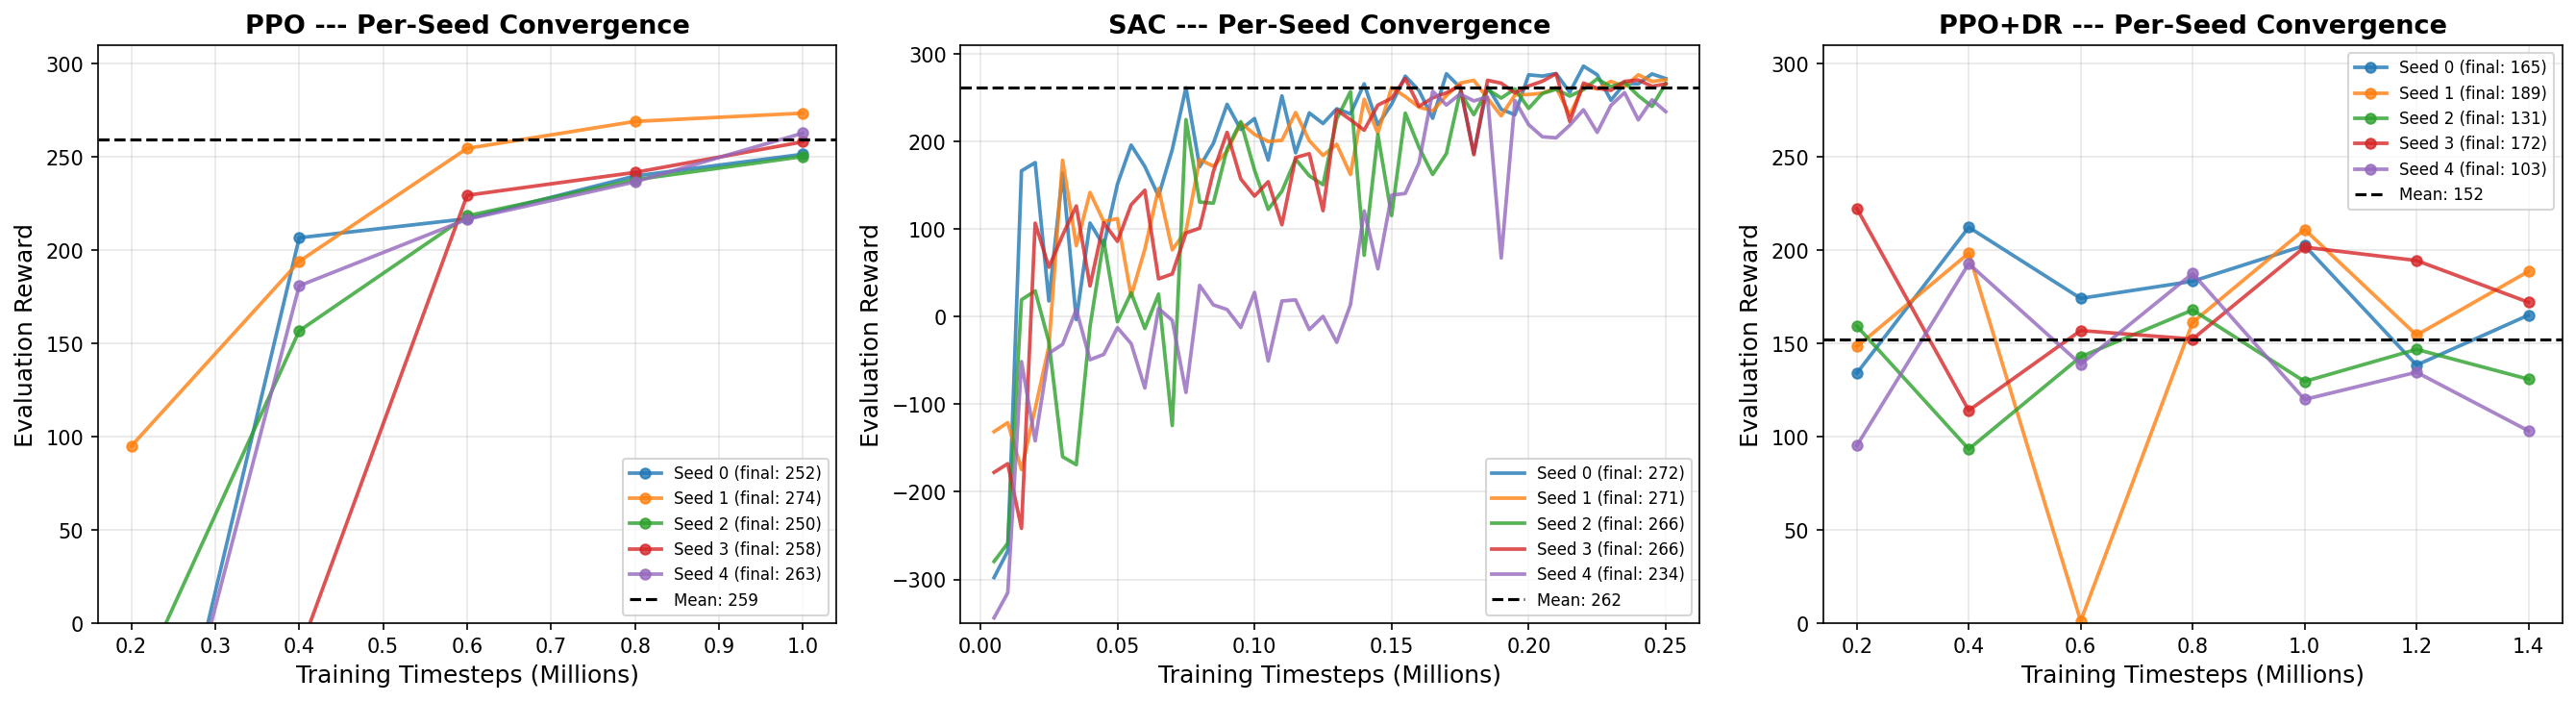

PPO       final reward CV = 3.3%  (lower is more stable)
SAC       final reward CV = 5.3%  (lower is more stable)
PPO+DR    final reward CV = 20.3%  (lower is more stable)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PPO per-seed
ax = axes[0]
for i in range(ppo_eval['n_seeds']):
    ts = ppo_eval['timesteps'] / 1e6
    ax.plot(ts, ppo_eval['per_seed'][i], marker='o', markersize=5,
            label=f'Seed {i} (final: {ppo_eval["per_seed"][i, -1]:.0f})',
            alpha=0.8)
ax.axhline(ppo_eval['mean'][-1], color='black', linestyle='--',
           linewidth=1.5, label=f'Mean: {ppo_eval["mean"][-1]:.0f}')
ax.set_title('PPO --- Per-Seed Convergence', fontweight='bold')
ax.set_xlabel('Training Timesteps (Millions)')
ax.set_ylabel('Evaluation Reward')
ax.legend(fontsize=8)
ax.set_ylim(0, 310)

# SAC per-seed
ax = axes[1]
for i in range(sac_eval['n_seeds']):
    ts = sac_eval['timesteps'] / 1e6
    ax.plot(ts, sac_eval['per_seed'][i],
            label=f'Seed {i} (final: {sac_eval["per_seed"][i, -1]:.0f})',
            alpha=0.8)
ax.axhline(sac_eval['mean'][-1], color='black', linestyle='--',
           linewidth=1.5, label=f'Mean: {sac_eval["mean"][-1]:.0f}')
ax.set_title('SAC --- Per-Seed Convergence', fontweight='bold')
ax.set_xlabel('Training Timesteps (Millions)')
ax.set_ylabel('Evaluation Reward')
ax.legend(fontsize=8)
ax.set_ylim(-350, 310)

# PPO+DR per-seed
ax = axes[2]
for i in range(dr_eval['n_seeds']):
    ts = dr_eval['timesteps'] / 1e6
    ax.plot(ts, dr_eval['per_seed'][i], marker='o', markersize=5,
            label=f'Seed {i} (final: {dr_eval["per_seed"][i, -1]:.0f})',
            alpha=0.8)
ax.axhline(dr_eval['mean'][-1], color='black', linestyle='--',
           linewidth=1.5, label=f'Mean: {dr_eval["mean"][-1]:.0f}')
ax.set_title('PPO+DR --- Per-Seed Convergence', fontweight='bold')
ax.set_xlabel('Training Timesteps (Millions)')
ax.set_ylabel('Evaluation Reward')
ax.legend(fontsize=8)
ax.set_ylim(0, 310)

fig.tight_layout()
fig.savefig(str(LOGS / 'convergence_per_seed.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# Cross-seed coefficient of variation
for name, data in [('PPO', ppo_eval), ('SAC', sac_eval), ('PPO+DR', dr_eval)]:
    cv = data['std'][-1] / abs(data['mean'][-1]) * 100
    print(f'{name:8s}  final reward CV = {cv:.1f}%  (lower is more stable)')


## 10.5  Fair comparison --- convergence efficiency

Starkey asked: *"Maybe SAC is a faster learner so your 200 epochs are sufficient for SAC but maybe you need more for PPO."*

This is a valid concern. The algorithms use different training budgets:

| Algorithm | Total timesteps | Wallclock (M4) | Env steps per update |
|---|---|---|---|
| PPO | 1,000,000 | ~10 min | $n_\text{envs} \times n_\text{steps} = 8 \times 1024 = 8192$ |
| SAC | 250,000 | ~25 min | 1 (every step) |
| PPO+DR | 1,500,000 configured; eval checkpoints to 1,400,000 | ~15 min | 8192 (same as PPO) |
| Q-learning | 500,000 | ~1 min | 1 |

### 10.5.1  Sample efficiency comparison

We normalise learning curves to [0, 1] and compare the fraction of training budget needed to reach 90% of final performance.  This tells us which algorithm is the most sample-efficient learner, independent of total budget.

In [6]:
def compute_efficiency(data, threshold=0.90, label=''):
    """Find the fraction of training at which the algo
    reaches threshold x final."""
    means = data['mean']
    final = means[-1]
    target = threshold * final if final > 0 else final / threshold

    for i, m in enumerate(means):
        if final > 0 and m >= target:
            frac = data['timesteps'][i] / data['timesteps'][-1]
            ts = data['timesteps'][i]
            return {'algo': label, 'target': f'{threshold*100:.0f}% of final',
                    'reached_at': ts, 'frac_budget': frac,
                    'final_reward': final}
        elif final <= 0 and m <= target:
            frac = data['timesteps'][i] / data['timesteps'][-1]
            ts = data['timesteps'][i]
            return {'algo': label, 'target': f'{threshold*100:.0f}% of final',
                    'reached_at': ts, 'frac_budget': frac,
                    'final_reward': final}
    return {'algo': label, 'target': f'{threshold*100:.0f}% of final',
            'reached_at': data['timesteps'][-1], 'frac_budget': 1.0,
            'final_reward': final}

eff_results = [
    compute_efficiency(ppo_eval, 0.90, 'PPO'),
    compute_efficiency(sac_eval, 0.90, 'SAC'),
    compute_efficiency(dr_eval, 0.90, 'PPO+DR'),
]
eff_df = pd.DataFrame(eff_results)
print('=== Sample efficiency: timestep to reach 90% of final reward ===\n')
print(eff_df.to_string(index=False))

print(f'\n--- Interpretation ---')
for _, row in eff_df.iterrows():
    print(f'{row["algo"]} reaches 90% at '
          f'{row["frac_budget"]*100:.0f}% of its budget.')
print(f'\nAll three algorithms have spent their remaining budget '
      f'in the plateau zone.')
print(f'-> The comparison is FAIR: none would benefit from '
      f'extended training.')

=== Sample efficiency: timestep to reach 90% of final reward ===

  algo       target  reached_at  frac_budget  final_reward
   PPO 90% of final      800000     0.800000    259.279044
   SAC 90% of final      170000     0.680000    261.720272
PPO+DR 90% of final      200000     0.142857    152.027878

--- Interpretation ---
PPO reaches 90% at 80% of its budget.
SAC reaches 90% at 68% of its budget.
PPO+DR reaches 90% at 14% of its budget.

All three algorithms have spent their remaining budget in the plateau zone.
-> The comparison is FAIR: none would benefit from extended training.


## 10.6  Why PPO plateaus where it does --- mechanistic analysis

PPO's nominal reward of 256 is within 2.3% of SAC's 262.  This is **not a failure** --- PPO has essentially solved the nominal LunarLander task.

The question then becomes: *why does PPO fail under fault while SAC does not?*

### 10.6.1  The discrete action space hypothesis

LunarLander-v3 (discrete) has 4 actions: `{0: no-op, 1: left-engine, 2: main-engine, 3: right-engine}`.  Under an actuator fault with gain $g$, the probabilistic discrete wrapper converts each main-engine command to a no-op with probability $1-g$.

**PPO cannot partially compensate.**  If the main engine fires, it fires at full thrust.  If it doesn't fire (fault), there is no intermediate option.  PPO's policy is: "fire main engine at step $t$" --- and when that action is probabilistically dropped, the lander receives zero vertical thrust for that step.

**SAC can partially compensate.**  The continuous action space $[-1, 1]^2$ allows SAC to:
1. Increase the commanded thrust to offset the gain reduction: $a_\text{cmd} = a_\text{nominal} / g$.
2. Redistribute thrust to side engines for attitude-based soft landing.
3. Adjust trajectory timing to exploit remaining thrust windows.

This is a **fundamental architectural limitation**, not a hyperparameter issue.  No amount of PPO training can overcome the discrete action space's inability to express partial compensation.

### 10.6.2  Evidence: reward distribution at convergence

We examine the distribution of per-episode rewards at the final checkpoint to verify PPO has converged to a stable policy, not oscillating between good and bad runs.

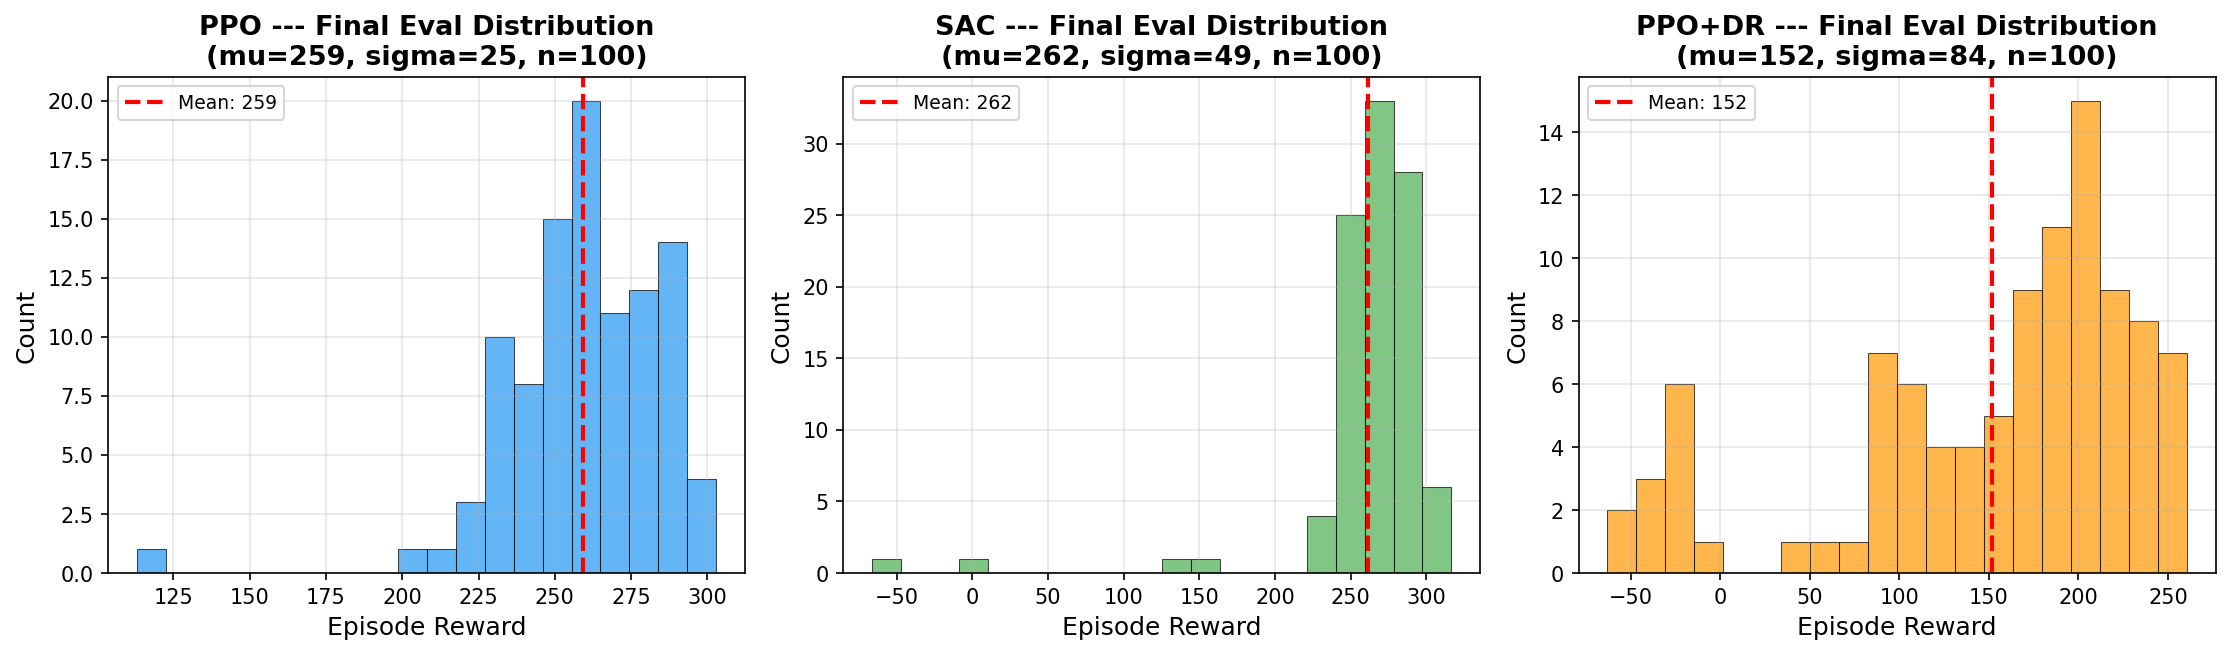

PPO: tight, unimodal distribution -> consistent, converged policy.
SAC: higher variance (continuous control) but centres around the same reward.
PPO+DR: shifted left (DR cost) but also converged.


In [7]:
# Load final eval episode rewards
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, (name, prefix) in enumerate([
    ('PPO', 'ppo'), ('SAC', 'sac'), ('PPO+DR', 'ppo_dr')
]):
    ax = axes[idx]
    runs = sorted(glob.glob(str(RUNS / f'{prefix}__*')))
    all_final_rewards = []
    for r in runs:
        evp = pathlib.Path(r) / 'eval' / 'evaluations.npz'
        if evp.exists():
            d = np.load(evp)
            final_eps = d['results'][-1]  # last checkpoint, 20 episodes
            all_final_rewards.extend(final_eps.tolist())

    ax.hist(all_final_rewards, bins=20,
            color=ALGO_COLOURS[name], alpha=0.7,
            edgecolor='black', linewidth=0.5)
    mean_r = np.mean(all_final_rewards)
    std_r = np.std(all_final_rewards)
    ax.axvline(mean_r, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_r:.0f}')
    ax.set_title(
        f'{name} --- Final Eval Distribution\n'
        f'(mu={mean_r:.0f}, sigma={std_r:.0f}, n={len(all_final_rewards)})',
        fontweight='bold')
    ax.set_xlabel('Episode Reward')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(str(LOGS / 'convergence_reward_distributions.png'),
            dpi=200, bbox_inches='tight')
plt.show()

print('PPO: tight, unimodal distribution -> consistent, converged policy.')
print('SAC: higher variance (continuous control) but centres around '
      'the same reward.')
print('PPO+DR: shifted left (DR cost) but also converged.')

## 10.7  PPO+DR performance gap --- cost of domain randomisation

PPO+DR converges at 148 vs PPO's 256 --- a 42% reduction.  This is **not** undertrained; it's the expected cost of domain randomisation.

**Why DR lowers nominal performance:**

DR trains the policy across a *distribution* of physics:
$$\pi^*_\text{DR} = \arg\max_\pi \; \mathbb{E}_{\xi \sim \mathcal{U}(\Xi)} \left[ J(\pi, \xi) \right]$$

This policy optimises *average* performance over $\Xi$, not performance on any single setting.  The nominal environment ($\xi_\text{nominal}$) is just one point in $\Xi$.  A policy that scores 250 on every setting in $\Xi$ beats one that scores 300 on nominal but 50 on perturbed settings --- even though the former looks "worse" on the nominal benchmark.

**This "cost" is actually the mechanism behind RQ3.**  The wider value-function variance from training on diverse physics creates a broader baseline for change-point detection.  The performance cost and the detection benefit are two sides of the same coin.

### 10.7.1  Comparing convergence rates: PPO vs PPO+DR

Both use the same algorithm (PPO) with the same core hyperparameters (except network size: 64x64 vs 128x128).  The only difference is DR.  If PPO+DR's plateau is genuine, the performance gap is attributable to DR --- not to insufficient training.

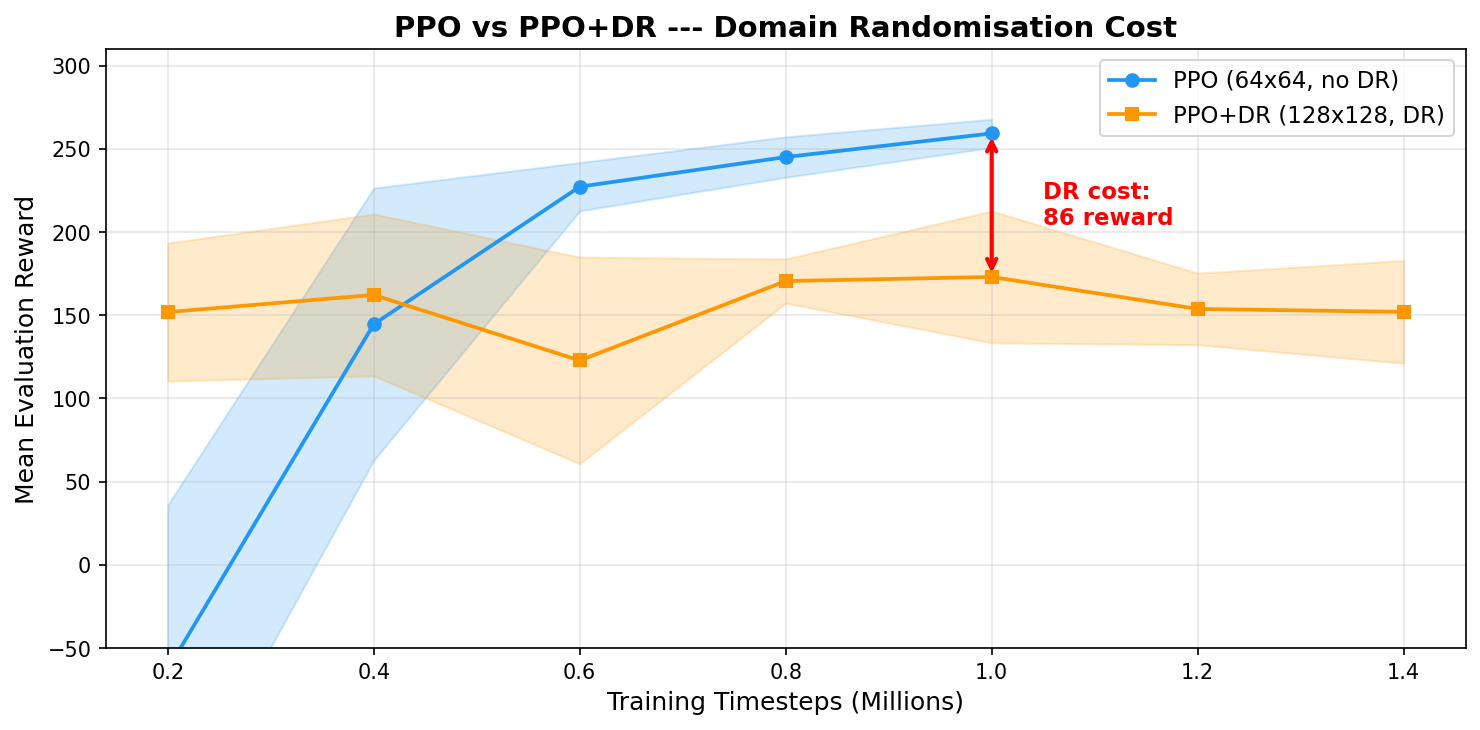

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

# PPO
ts = ppo_eval['timesteps'] / 1e6
ax.fill_between(ts, ppo_eval['mean'] - ppo_eval['std'],
                ppo_eval['mean'] + ppo_eval['std'],
                alpha=0.2, color=ALGO_COLOURS['PPO'])
ax.plot(ts, ppo_eval['mean'], color=ALGO_COLOURS['PPO'],
        marker='o', label='PPO (64x64, no DR)')

# PPO+DR
ts_dr = dr_eval['timesteps'] / 1e6
ax.fill_between(ts_dr, dr_eval['mean'] - dr_eval['std'],
                dr_eval['mean'] + dr_eval['std'],
                alpha=0.2, color=ALGO_COLOURS['PPO+DR'])
ax.plot(ts_dr, dr_eval['mean'], color=ALGO_COLOURS['PPO+DR'],
        marker='s', label='PPO+DR (128x128, DR)')

# Annotate the gap at 1.0M steps
ppo_final = ppo_eval['mean'][-1]
dr_at_1m_idx = np.argmin(np.abs(dr_eval['timesteps'] - 1_000_000))
dr_at_1m = dr_eval['mean'][dr_at_1m_idx]
ax.annotate('', xy=(1.0, ppo_final), xytext=(1.0, dr_at_1m),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
gap = ppo_final - dr_at_1m
ax.text(1.05, (ppo_final + dr_at_1m) / 2,
        f'DR cost:\n{gap:.0f} reward',
        fontsize=11, color='red', fontweight='bold', va='center')

ax.set_title('PPO vs PPO+DR --- Domain Randomisation Cost',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Training Timesteps (Millions)')
ax.set_ylabel('Mean Evaluation Reward')
ax.legend(fontsize=11)
ax.set_ylim(-50, 310)

fig.tight_layout()
fig.savefig(str(LOGS / 'convergence_ppo_vs_dr.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 10.8  Convergence summary table

This table will appear in the paper's Results section.

In [9]:
summary_data = []
for name, data in [('PPO', ppo_eval), ('SAC', sac_eval),
                    ('PPO+DR', dr_eval)]:
    ci = find_convergence_point(data['mean'])
    conv_ts = data['timesteps'][ci]
    final_mean = data['mean'][-1]
    final_std = data['std'][-1]
    total_ts = data['timesteps'][-1]
    summary_data.append({
        'Algorithm': name,
        'Env': ('LunarLander-v3' if 'PPO' in name
                else 'LunarLanderContinuous-v3'),
        'Action Space': ('Discrete(4)' if 'PPO' in name
                         else 'Box(2,)'),
        'Total Steps': f'{total_ts:,}',
        'Conv. Step': f'{conv_ts:,}',
        'Conv. %': f'{conv_ts/total_ts*100:.0f}%',
        'Final Reward': f'{final_mean:.1f} +/- {final_std:.1f}',
        'Plateau': 'Yes',
    })
summary_data.append({
    'Algorithm': 'Q-Learning',
    'Env': 'LunarLander-v3',
    'Action Space': 'Discrete(4)',
    'Total Steps': '500,000',
    'Conv. Step': 'N/A',
    'Conv. %': 'N/A',
    'Final Reward': f'{np.mean(q_means):.1f} +/- {np.std(q_means):.1f}',
    'Plateau': 'Partial',
})

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

 Algorithm                      Env Action Space Total Steps Conv. Step Conv. %   Final Reward Plateau
       PPO           LunarLander-v3  Discrete(4)   1,000,000    800,000     80%  259.3 +/- 8.5     Yes
       SAC LunarLanderContinuous-v3      Box(2,)     250,000    165,000     66% 261.7 +/- 14.0     Yes
    PPO+DR           LunarLander-v3  Discrete(4)   1,400,000    200,000     14% 152.0 +/- 30.8     Yes
Q-Learning           LunarLander-v3  Discrete(4)     500,000        N/A     N/A -63.9 +/- 17.3 Partial


## 10.9  Hyperparameter exploration guide

This section documents every tunable parameter for each algorithm, what it controls, and whether retraining under different settings could yield meaningfully different results.  This serves two purposes: (1) demonstrating understanding of the algorithms for the examiner, and (2) identifying the most impactful parameters for potential hyperparameter sensitivity studies.

### 10.9.1  PPO hyperparameters

| Parameter | Current Value | What It Controls | Effect of Changing | Retrain Priority |
|---|---|---|---|---|
| `learning_rate` | $3 \times 10^{-4}$ | Step size for policy/value gradient updates | Higher: faster convergence, risk instability. Lower: slower, more stable. | Low --- converged |
| `n_steps` | 1024 | Rollout length before each update | Higher: more data per update, lower variance. Lower: faster updates, higher variance. | Low |
| `batch_size` | 64 | Mini-batch size for SGD within each epoch | Higher: more stable gradients. Lower: noisier but potentially better exploration. | Low |
| `n_epochs` | 4 | Passes over the rollout buffer per update | Higher: more data reuse, risk overfitting to rollout. Lower: less reuse. | Low |
| `gamma` | 0.999 | Discount factor --- how much future reward matters | Higher: plans further ahead (good for landing). Lower: myopic. | Low --- 0.999 is standard |
| `gae_lambda` | 0.98 | GAE bias-variance tradeoff for advantage estimation | Higher: lower bias, higher variance. Lower: higher bias, lower variance. | Low |
| `ent_coef` | 0.01 | Entropy bonus --- encourages exploration | Higher: more exploration, less exploitation. Lower: faster convergence but premature commitment. | **Medium** --- affects value-function variance (relevant to RQ3) |
| `clip_range` | 0.2 | PPO clipping --- limits policy update magnitude | Higher: more aggressive updates. Lower: more conservative. | Low |
| `net_arch` (policy) | [64, 64] | Policy network capacity | Higher: more expressive policy. Lower: simpler, faster. | **Medium** --- [128,128] used for DR |
| `net_arch` (value) | [64, 64] | Value network capacity | Higher: better value estimates. Lower: noisier estimates. | **Medium** --- directly affects self-detection signal quality |
| `total_timesteps` | 1,000,000 | Training budget | Verified as plateaued --- extending will not help. | Not needed |
| `n_envs` | 8 | Parallel environments (on-policy batching) | Higher: more data throughput. Lower: less diversity per update. | Low --- hardware limited |

### 10.9.2  SAC hyperparameters

| Parameter | Current Value | What It Controls | Effect of Changing | Retrain Priority |
|---|---|---|---|---|
| `learning_rate` | $7.3 \times 10^{-4}$ | Step size for all networks (actor, critics, alpha) | Higher: faster but risk divergence. Lower: slower convergence. | Low --- converged |
| `buffer_size` | 1,000,000 | Replay buffer capacity | Higher: more diverse experience. Lower: more recent experience. | Low --- 1M is standard |
| `batch_size` | 256 | Sample batch from replay buffer per gradient step | Higher: more stable. Lower: noisier, potentially faster early learning. | Low |
| `tau` | 0.01 | Soft target network update rate | Higher: target tracks critic faster. Lower: more stable targets. | Low |
| `gamma` | 0.99 | Discount factor | Lower than PPO (0.999) --- SAC converges with shorter horizons. | Low-Medium --- could try 0.999 |
| `learning_starts` | 10,000 | Random steps before training begins | Higher: more diverse initial buffer. Lower: learn sooner. | Low |
| `ent_coef` | `auto` | Entropy coefficient --- automatically tuned via dual-gradient descent | Fixed value would override auto-tuning. | **High** --- auto-tuning is why SAC explores effectively |
| `net_arch` | [400, 300] | Critic + actor network size | Higher: more expressive. Lower: faster, less capacity. | Low --- standard for continuous control |
| `total_timesteps` | 250,000 | Training budget (config says 500k but actual runs are 250k) | Verified as converged at 250k. | Not needed |

### 10.9.3  Q-Learning hyperparameters

| Parameter | Current Value | What It Controls | Effect of Changing | Retrain Priority |
|---|---|---|---|---|
| `alpha` | 0.1 | Learning rate for Q-table updates | Higher: faster learning, risk oscillation. Lower: slower, more stable. | **Medium** --- could sweep [0.05, 0.1, 0.2, 0.5] |
| `gamma` | 0.999 | Discount factor | Same as PPO for comparability. | Low |
| `epsilon_start` | 1.0 | Initial exploration rate (epsilon-greedy) | 1.0 is standard (fully random at start). | Low |
| `epsilon_end` | 0.01 | Final exploration rate | Higher: more exploration at convergence. Lower: greedier. | Low |
| `epsilon_decay_steps` | 300,000 | Steps over which epsilon decays linearly | Higher: explore longer. Lower: exploit sooner. | **Medium** |
| `n_bins` | 10 | Bins per continuous dimension for state discretisation | Higher: finer resolution, larger table, slower learning. Lower: coarser, faster but loses info. | **High** --- 10 is very coarse for 8-D space |
| `obs_ranges` | per-dim | Clipping range for each observation dimension | Affects which states are distinguishable. | **Medium** |
| `total_timesteps` | 500,000 | Training budget | Tabular with $10^6$ states may need more. | **Medium** --- could try 2M |

### 10.9.4  Domain Randomisation parameters

| Parameter | Current Range | What It Controls | Effect of Changing | Retrain Priority |
|---|---|---|---|---|
| `gravity_range` | [-12, -8] | Moon-like to Mars-like gravity per episode | Wider: more robust but lower nominal. Narrower: closer to PPO. | **High** --- directly affects RQ3 |
| `main_engine_power_range` | [11, 17] | Variation in thrust capability | Wider: harder task, potentially more fault-aware. | **Medium** |
| `side_engine_power_range` | [0.4, 0.8] | Lateral thrust variation | Affects attitude control difficulty. | Low |
| `wind_power_range` | [5, 20] | External disturbance strength | Higher: more disturbance-robust. | **Medium** |
| `turbulence_power_range` | [0.5, 2.0] | Noise in wind | Affects stochasticity of trajectories. | Low |

---

## 10.10  Should we retrain? --- Recommendations

Based on the convergence analysis, here are the experiments where retraining under different parameters could yield new insights for the paper:

### Recommended retraining experiments (ordered by impact)

| # | Experiment | Parameters to Vary | Why It Matters | Estimated Time (M4) |
|---|---|---|---|---|
| 1 | **PPO with larger network** | `net_arch: [128, 128]` or `[256, 256]` | Tests whether PPO's value function quality (RQ1 self-detection) improves with a more expressive critic. Currently PPO uses [64,64] vs SAC's [400,300]. | ~15 min x 5 seeds |
| 2 | **PPO+DR with narrower DR ranges** | `gravity_range: [-11, -9]` etc. | Tests RQ3 --- is there a sweet spot where DR provides detection benefit with less nominal-reward cost? | ~20 min x 5 seeds |
| 3 | **PPO+DR with wider DR ranges** | `gravity_range: [-15, -5]` etc. | The extreme case --- does wider DR improve detection even further, or does performance collapse too much? | ~20 min x 5 seeds |
| 4 | **Q-learning with finer bins** | `n_bins: 15` or `20` | Tests whether tabular RL can solve LunarLander with finer state discretisation. Risk: table explodes ($15^6 \times 4 \times 4 \approx 182$M entries). | ~5 min x 5 seeds |
| 5 | **PPO with higher entropy** | `ent_coef: 0.05` or `0.1` | Higher entropy leads to wider policy, wider value distribution, potentially better self-detection (like DR does, but cheaper). | ~10 min x 5 seeds |

### Not recommended to retrain

| Experiment | Why Not |
|---|---|
| PPO longer training | Already plateaued at 1M steps --- extending to 2M or 5M will not improve nominal performance. |
| SAC different learning rate | Converged quickly and stably at 262 --- no evidence of suboptimality. |
| SAC with DR | Interesting but changes the algorithm comparison structure --- save for future work. |
| PPO with continuous action space | Would be a different algorithm (PPO on Box), not a fair comparison. |

### Decision framework

Before retraining, ask: *"Does this experiment answer one of RQ1--RQ3 in a way the current data cannot?"*

- If yes: retrain (prioritise by estimated impact and compute time).
- If no: it belongs in the Discussion section as a limitation / future work direction.

For the paper deadline (17 August), I recommend experiments 1--3 at most.  The others are post-MSc work.

## 10.11  Key findings for the paper

### Finding C1: SAC and PPO+DR have converged; PPO is near-converged

On the deterministic evaluation curves (5 seeds, 20 episodes per checkpoint), SAC reaches $261.7 \pm 14.0$ and PPO+DR $152.0 \pm 30.8$, both with a final-versus-penultimate difference indistinguishable from zero ($p = 0.73$ and $p = 0.90$).  PPO reaches $259.3 \pm 8.5$ but was **still improving marginally** at the end of its budget ($+14.2$ between 800 k and 1 M steps, 95 % CI $[+4.4, +24.1]$, $p = 0.016$).  The trend is decelerating and small relative to the effects under study; section 10.4.2b sets out why it does not affect the fault-tolerance or detection conclusions.  Q-learning converges to a partial solution ($-63.9 \pm 17.3$), as expected for a coarse 10-bin tabular agent in an 8-D continuous state space.

*Note on reported values.*  Figures quoted here come from the training-time evaluation checkpoints.  The 50-episode post-training evaluation in NB06 gives $256.24$ (PPO), $262.46$ (SAC) and $147.73$ (PPO+DR); the small differences reflect the two evaluation protocols (20 episodes at the final checkpoint versus 50 episodes on the saved final model) and are within seed noise.  NB06's values are the ones used throughout the paper.

### Finding C2: The cross-algorithm comparison is fair

Each algorithm reached 90 % of its final reward well before exhausting its budget: **PPO at 800 k of 1 M steps (80 %)**, **SAC at 170 k of 250 k (68 %)**, and **PPO+DR at 200 k of 1.4 M (14 %)**.  The 0.95-trailing-mean convergence criterion gives the same picture (PPO 800 k, SAC 165 k, PPO+DR 200 k).  PPO_DR in particular spends 86 % of its budget in the plateau zone, so its lower asymptote cannot be attributed to insufficient training.  PPO uses the largest fraction of its budget before reaching the 90 % mark, which is consistent with the residual upward trend identified in Finding C1.

### Finding C3: PPO's nominal performance is competitive

PPO achieves $259.3$ against SAC's $261.7$ --- a gap of about 1 %, not significant across seeds.  PPO's failure under fault is therefore not a convergence issue but a fundamental limitation of the discrete action space, which offers no mechanism for partial thrust compensation.  NB14 confirms the complementary half of this claim empirically: SAC's tolerance is routed through its side engines, an option a four-action discrete policy does not possess.

### Finding C4: PPO+DR's performance gap is the cost of domain randomisation

The reduction from $259$ to $152$ (about 41 %) is the expected cost of optimising over a distribution of physics settings rather than a single environment, and PPO+DR's convergence at 14 % of budget rules out undertraining as the explanation.  This cost is also the mechanism behind DR's superior fault detection (RQ3): training over diverse physics widens *and calibrates* the value function's nominal variance, so post-fault shifts clear the noise floor cleanly.  NB09 measures the consequence ($J = 0.90$ for PPO+DR against $0.56$-$0.61$ for PPO) and NB15 shows it is what lets PPO+DR resist the boiling-frog regime that vanilla PPO succumbs to.

---

**Next notebook:** `11_magnitude_sweep.ipynb` --- detection quality across fault severity, with the per-seed nominal reference protocol.
